# Проект\. Часть 6

## HR Analytics: Employee Attrition & Performance

Источник \(данные не менялись\): Kaggle https://www\.kaggle\.com/datasets/pavansubhasht/ibm\-hr\-analytics\-attrition\-dataset/data

Цель проекта: исследовать факторы, влияющие на текучесть кадров \(Attrition\) и определить, какие характеристики сотрудников повышают вероятность их ухода из компании\.

Задача для предсказания: предсказать, уйдёт ли сотрудник из компании, основываясь на данных о нём и его работе \(задача классификации\)\. 

Итоговая модель — стекинг \(логистическая регрессия \+ AdaBoost\)\. Она выбрана как лучшая ансамблевая модель по качеству\.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier

In [2]:
# загрузка данных
data = pd.read_csv("datasets/HR-Employee-Attrition.csv")

columns_to_drop = ['EducationField', 'JobRole', 'PerformanceRating', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'HourlyRate', 'MonthlyRate']
data = data.drop(columns=columns_to_drop)

data = pd.get_dummies(data, columns=['Attrition', 'BusinessTravel', 'Department', 'Gender', 'OverTime', 'MaritalStatus'], drop_first=True)

In [3]:
y = data["Attrition_Yes"]
X = data.drop(columns="Attrition_Yes")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0, stratify=y)

In [4]:
# модели для стекинга
logC = LogisticRegression(solver="liblinear", max_iter=1000)
logC.fit(X_train, y_train)

modelAB = AdaBoostClassifier(estimator=logC, n_estimators=100)
modelAB.fit(X_train, y_train)

# стекинг
pred1_train = pd.DataFrame(modelAB.predict(X_train))
pred2_train = pd.DataFrame(logC.predict(X_train))

pred1_test = pd.DataFrame(modelAB.predict(X_test))
pred2_test = pd.DataFrame(logC.predict(X_test))

data_train = pd.concat([pred1_train, pred2_train], axis=1)
data_test = pd.concat([pred1_test, pred2_test], axis=1)

modelSt = LogisticRegression(solver="liblinear")
modelSt.fit(data_train, y_train)
modelSt.score(data_train, y_train), modelSt.score(data_test, y_test)

(0.8744897959183674, 0.8755102040816326)

### Глобальная интерпретация — permutation importance

In [5]:
!pip install eli5


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
from eli5.permutation_importance import get_score_importances

# функция качества всей стекинговой системы
def stacked_score(X_input, y_true):
    p1 = pd.DataFrame(modelAB.predict(X_input))
    p2 = pd.DataFrame(logC.predict(X_input))
    meta = pd.concat([p1, p2], axis=1)
    return modelSt.score(meta, y_true)

base_score, score_decreases = get_score_importances(stacked_score, X_test.values, y_test.values)

feature_importance = np.mean(score_decreases, axis=0)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

importance_df.head(15)

2026-02-28 23:01:39.784207: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772319699.804028      59 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772319699.810003      59 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772319699.825970      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772319699.825992      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772319699.825995      59 computation_placer.cc:177] computation placer alr

,feature,importance
25,OverTime_Yes,0.030204
13,TotalWorkingYears,0.017959
8,MonthlyIncome,0.014694
9,NumCompaniesWorked,0.013061
2,DistanceFromHome,0.012653
7,JobSatisfaction,0.011837
19,YearsWithCurrManager,0.011429
27,MaritalStatus_Single,0.010204
17,YearsInCurrentRole,0.008163
23,Department_Sales,0.006531


Наиболее значимые признаки — те, удаление которых сильнее всего ухудшает точность стекинговой модели\. Это факторы, которые сильнее всего влияют именно на предсказание модели, но не обязательно на реальное поведение сотрудников\.

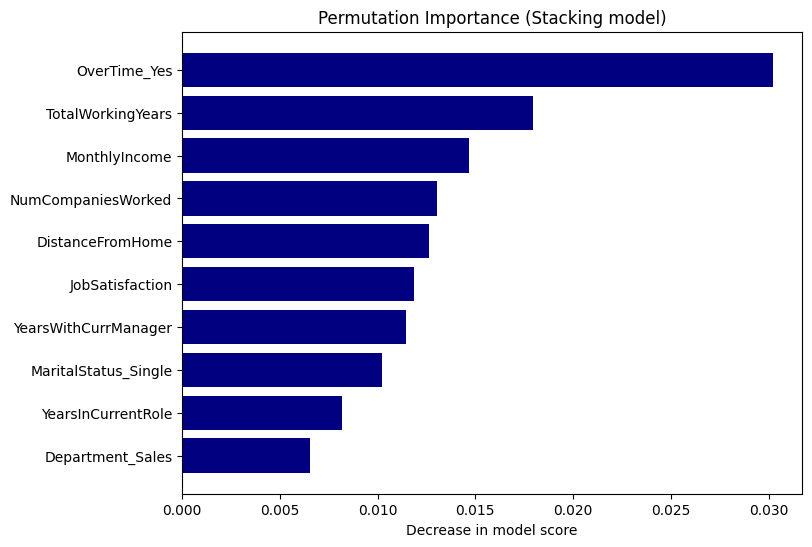

In [7]:
plt.figure(figsize=(8,6))
plt.barh(importance_df.head(10)["feature"][::-1], 
    importance_df.head(10)["importance"][::-1], 
    color='navy')
plt.title("Permutation Importance (Stacking model)")
plt.xlabel("Decrease in model score")
plt.show()

В полученных результатах наиболее сильное влияние на предсказание оказывает наличие переработок \(OverTime\_Yes\): перемешивание этого признака сильнее всего ухудшает качество модели, значит он несёт ключевую информацию для прогнозирования увольнения\. Далее по значимости следуют общий трудовой стаж \(TotalWorkingYears\) и уровень дохода \(MonthlyIncome\), что указывает на заметную роль карьерного опыта и финансовых условий в формировании прогноза\. Существенный вклад также дают количество сменённых работодателей \(NumCompaniesWorked\) и расстояние до работы \(DistanceFromHome\), отражающие профессиональную стабильность и повседневные условия занятости\. Удовлетворённость работой \(JobSatisfaction\) и длительность работы с текущим руководителем \(YearsWithCurrManager\) оказывают умеренное влияние на предсказание, подтверждая важность организационной среды\. Семейное положение \(MaritalStatus\_Single\) и стаж в текущей роли \(YearsInCurrentRole\) влияют слабее, но всё ещё вносят вклад в модель\.

### Динамика изменения предсказаний \(ICE \+ PDP\)

In [8]:
!pip install pycebox

  Preparing metadata (setup.py) ... done
  Created wheel for pycebox: filename=pycebox-0.0.1-py3-none-any.whl size=3662 sha256=587e07e785e85419ac358dc7ebd96ebd66e79df43f44bb8bf808b95de24feba0
  Stored in directory: /root/.cache/pip/wheels/b7/eb/8b/a6716f12a629b3dff6c3de159e42015252cb88ddafbbf9c668
Successfully built pycebox

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


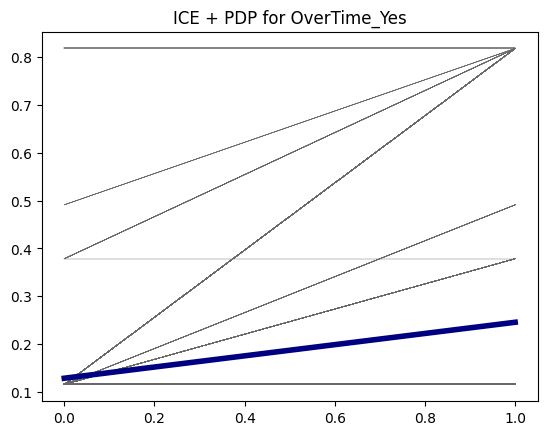

In [9]:
from pycebox.ice import ice, ice_plot

X_train_df = X_train.copy()

def stacked_predict_proba(X_input):
    p1 = pd.DataFrame(modelAB.predict(X_input))
    p2 = pd.DataFrame(logC.predict(X_input))
    meta = pd.concat([p1, p2], axis=1)
    return modelSt.predict_proba(meta)[:,1]

top_feature = importance_df.iloc[0]["feature"]
ice_data = ice(data=X_train_df, column=top_feature, predict=stacked_predict_proba)

ice_plot(ice_data, linewidth=0.3, c='dimgray', plot_pdp=True, 
    pdp_kwargs={'c': 'navy', 'linewidth': 4})

plt.title(f"ICE + PDP for {top_feature}")
plt.show()

Для OverTime\_Yes наблюдается возрастающая зависимость: наличие переработок прямо увеличивает вероятность увольнения\.

/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


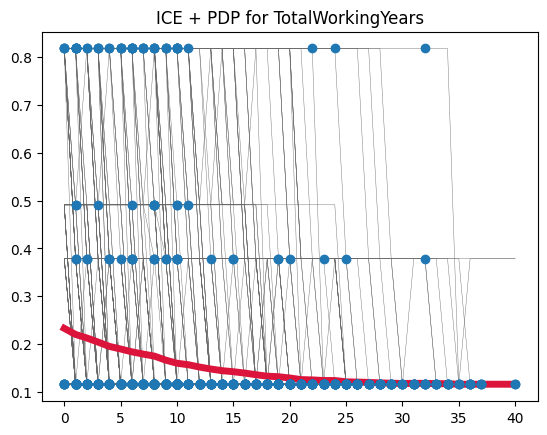

In [10]:
feature2 = 'TotalWorkingYears'
ice_data = ice(data=X_train_df, column=feature2, predict=stacked_predict_proba)

ice_plot(ice_data, linewidth=0.3, c='dimgray', plot_pdp=True, 
    pdp_kwargs={'c': 'crimson', 'linewidth': 5}, plot_points=True)

plt.title(f"ICE + PDP for {feature2}")
plt.show()

/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


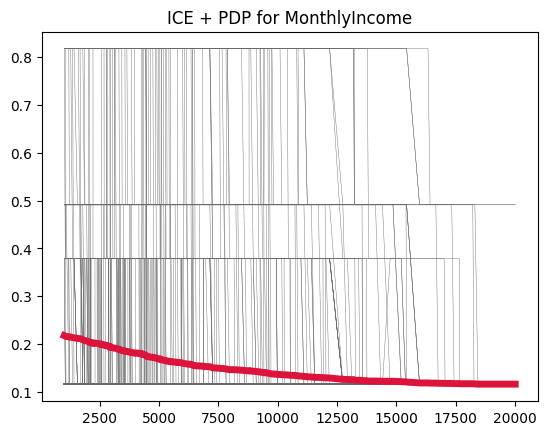

In [11]:
feature3 = 'MonthlyIncome'
ice_data = ice(data=X_train_df, column=feature3, predict=stacked_predict_proba)

ice_plot(ice_data, linewidth=0.3, c='dimgray', plot_pdp=True, 
    pdp_kwargs={'c': 'crimson', 'linewidth': 5})

plt.title(f"ICE + PDP for {feature3}")
plt.show()

Для TotalWorkingYears и MonthlyIncome PDP плавно убывает: с ростом общего стажа и дохода вероятность увольнения постепенно снижается\.

### Выбор наблюдений для локальной интерпретации

Выбраны два наблюдения:
1. сотрудник с максимальной вероятностью ухода
2. сотрудник с минимальной вероятностью ухода

Это позволяет увидеть, какие признаки увеличивают риск, а какие уменьшают его.

In [30]:
proba = stacked_predict_proba(X_test)

high_risk_idx = np.argmax(proba)
low_risk_idx = np.argmin(proba)

high_risk_idx, low_risk_idx

(33, 0)

Проверка, правильно ли были предсказаны классы:

In [33]:
# истинные значения
true_high = y_test.iloc[high_risk_idx]
true_low = y_test.iloc[low_risk_idx]

# предсказанные классы
pred_high = (proba[high_risk_idx] >= 0.5)
pred_low = (proba[low_risk_idx] >= 0.5)

print("High risk employee:")
print("True:", true_high, "Pred:", pred_high)

print("Low risk employee:")
print("True:", true_low, "Pred:", pred_low)

High risk employee:
True: True Pred: True
Low risk employee:
True: False Pred: False


Значения совпадают, значит, предсказания были верными\.

### Локальная интерпретация — SHAP

In [13]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 103.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.1 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
deepnote-toolkit 2.1.2 requires numpy<2,>=1.26.0; python_version == "3.12", but you have numpy 2.4.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
import shap

# SHAP для рандомной подвыборки
background = X_train.sample(100, random_state=0)
explainer = shap.KernelExplainer(stacked_predict_proba, background)
shap_values = explainer.shap_values(X_test.iloc[:50])

/root/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
  0%|          | 0/50 [00:00<?, ?it/s]/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Logisti

SHAP показывает вклад каждого признака в изменение вероятности относительно среднего уровня\. Положительный вклад увеличивает вероятность ухода, отрицательный — снижает\.

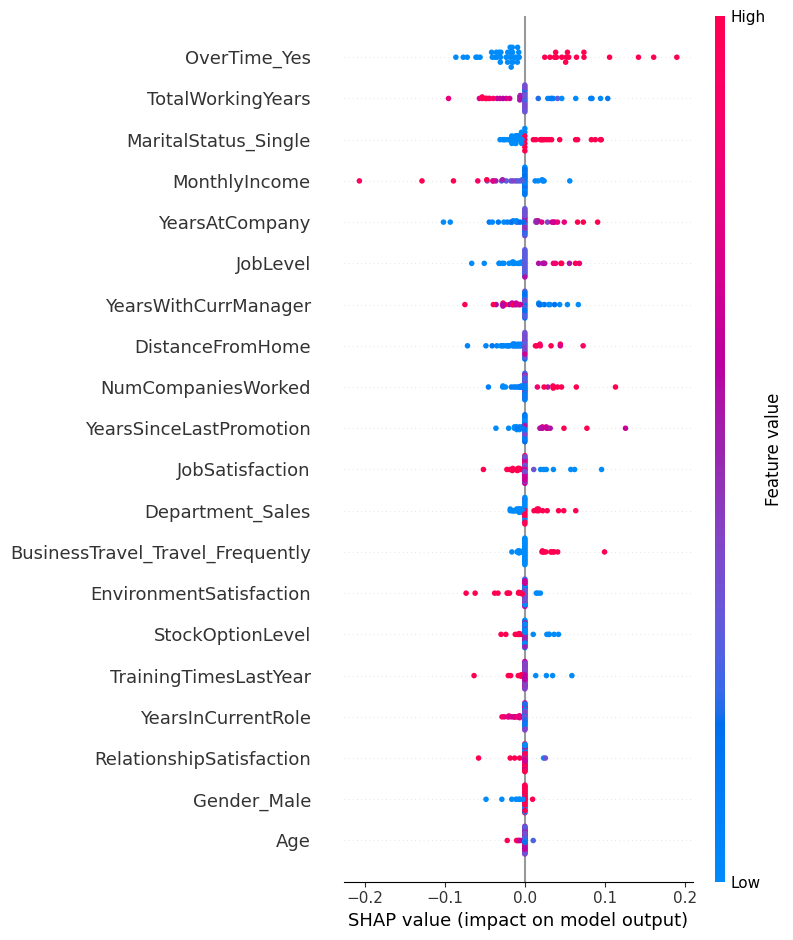

In [15]:
shap.summary_plot(shap_values, X_test.iloc[:50])

Модель считает ключевыми факторами:

- OverTime_Yes (переработки) — самый сильный фактор ухода
- TotalWorkingYears (общий стаж)
- MonthlyIncome (доход)
- MaritalStatus_Single (не в отношениях)
- YearsAtCompany (стаж в компании)
- JobLevel (уровень должности)
- YearsWithCurrManager (работа с текущим руководителем)
- DistanceFromHome (расстояние до работы)
- NumCompaniesWorked (число работодателей)
- YearsSinceLastPromotion (время без повышения)

Анализ локальной интерпретации модели с использованием SHAP показывает, что ключевые признаки оказывают различную по силе степень влияния на предсказание вероятности увольнения сотрудников, при этом наиболее важным фактором с точки зрения предсказания так же, как и в глобальной интерпретации, является наличие переработок (OverTime_Yes), показывающее наибольший средний вклад в изменение прогноза. Существенное влияние на предсказание также оказывают общий трудовой стаж (TotalWorkingYears: новички уходят чаще; опытные сотрудники удерживаются лучше), уровень дохода (MonthlyIncome: высокий доход снижает вероятность предсказания ухода), семейное положение (MaritalStatus_Single: вероятность ухода у одиноких сотрудников выше), стаж в компании (YearsAtCompany) и уровень должности (JobLevel).

In [16]:
rows_to_explain = X_test.iloc[[high_risk_idx, low_risk_idx]]

shap_values_selected = explainer.shap_values(rows_to_explain)

  0%|          | 0/2 [00:00<?, ?it/s]/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
 50%|█████     | 1/2 [00:07<00:07,  7.01s/it]/root/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassi

In [17]:
if isinstance(shap_values_selected, list):
    shap_vals = shap_values_selected[0]
else:
    shap_vals = shap_values_selected

Пример 1 — для сотрудника с высокой вероятностью ухода

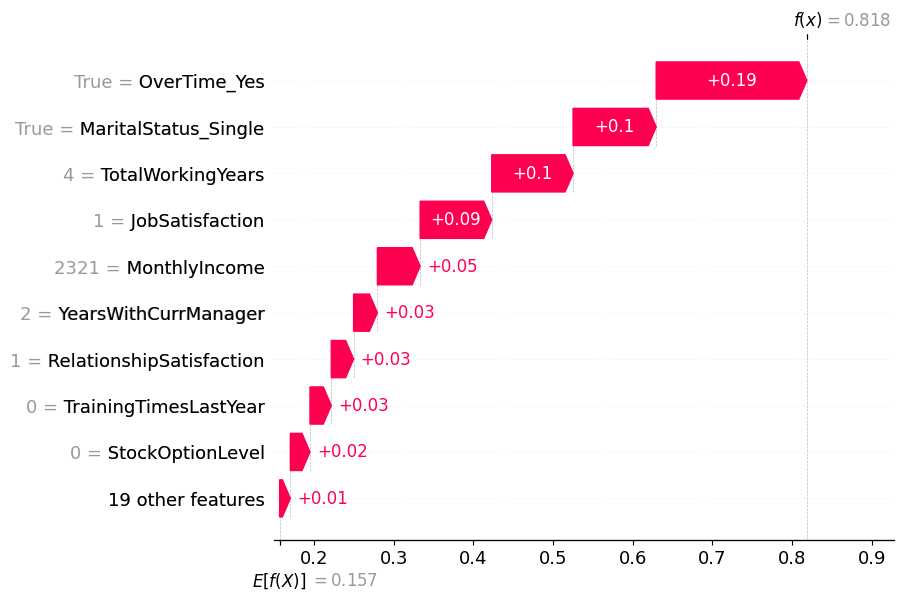

In [18]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals[0],
        base_values=explainer.expected_value,
        data=rows_to_explain.iloc[0],
        feature_names=X_test.columns
    )
)

Этот человек перерабатывал, мало зарабатывал, был неудовлетворён и работой, и отношениями с коллегами, а также у него не было партнёра в личной жизни\. Все эти вещи увеличивали его вероятность ухода из компании: его не держала ни сама работа, ни обязательства перед семьёй\.

In [19]:
print("HIGH RISK employee index:", high_risk_idx)
print("Predicted probability:", proba[high_risk_idx])

HIGH RISK employee index: 33
Predicted probability: 0.8184155467594759


Пример 2 — для сотрудника с низкой вероятностью ухода

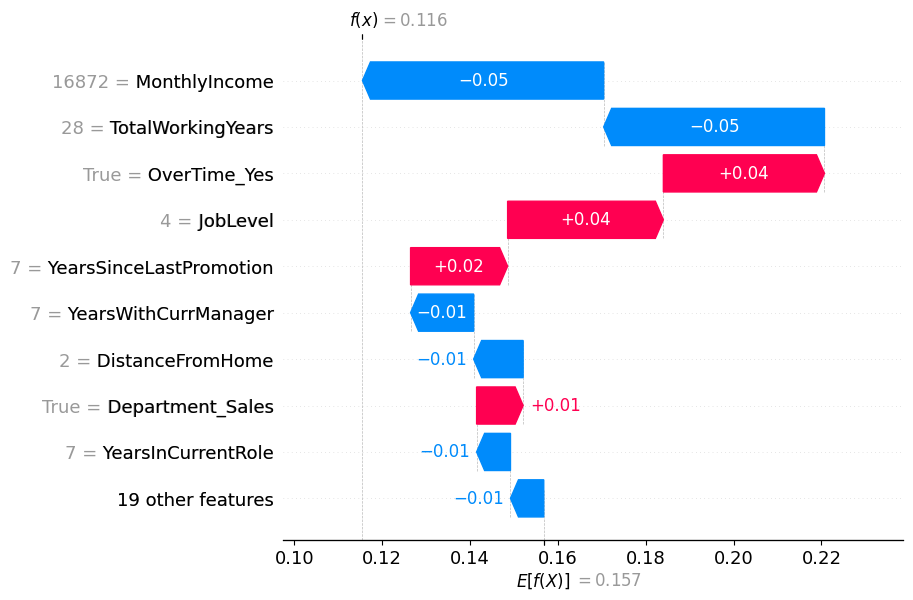

In [20]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals[1],
        base_values=explainer.expected_value,
        data=rows_to_explain.iloc[1],
        feature_names=X_test.columns
    )
)

Этот график выглядит уже более интересно: здесь есть и факторы, которые снижали вероятность ухода, и те, которые увеличивали её, но тот факт, что этот сотрудник очень много зарабатывал и имел уже очень солидный стаж, сильно перевесил все те факторы, которые смещали предсказание в сторону ухода\. Например, он тоже перерабатывал, но в данном случае это был далеко не решающий фактор\.

In [21]:
print("LOW RISK employee index:", low_risk_idx)
print("Predicted probability:", proba[low_risk_idx])

LOW RISK employee index: 0
Predicted probability: 0.11550001682816141


### Вывод:

Наиболее значимыми переменными оказались переработки, трудовой стаж и доход, что указывает на ключевую роль рабочей нагрузки и карьерно\-экономической стабильности в формировании риска увольнения: перегруженные, менее опытные и менее обеспеченные сотрудники уходят чаще\. Глобальная интерпретация дала схожие результаты с локальной на множественных наблюдениях с помощью метода SHAP, но при рассмотрении конкретных сотрудников видно, что вклад в вероятность их ухода был от разных особенностей их работы и жизни\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ff5c65e0-9edf-47b2-8d5a-439e7f5c1ece' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>